<a href="https://colab.research.google.com/github/Friskkun/Project-coding-storage/blob/main/Complex_model_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All possible splits and total payoff:
n0=5, n1=0, total payoff=0.6767
n0=4, n1=1, total payoff=2.2986
n0=3, n1=2, total payoff=3.5846
n0=2, n1=3, total payoff=3.5846
n0=1, n1=4, total payoff=2.2986
n0=0, n1=5, total payoff=0.6767

Best split:
n0=3, n1=2, ideal total payoff=3.5846
Ideal average payoff per agent=0.7169


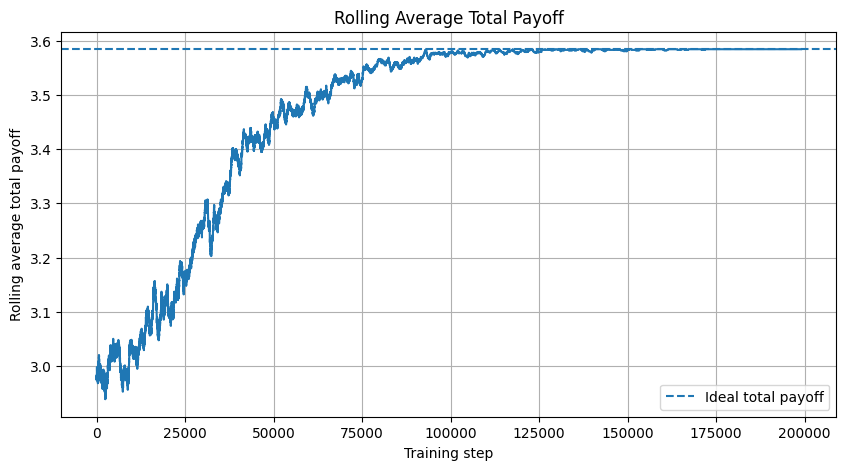

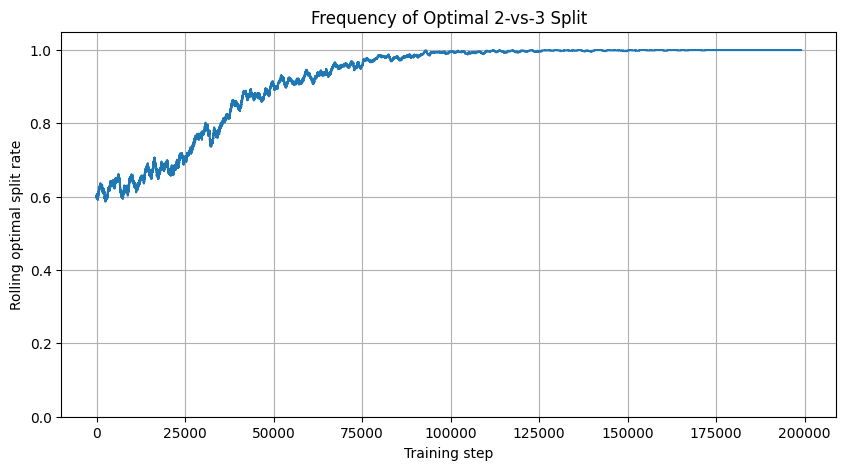

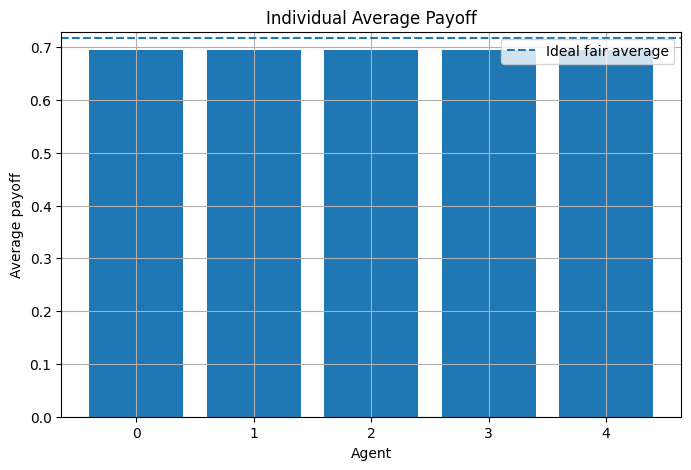


Final individual average payoffs:
Agent 0: 0.6943
Agent 1: 0.6945
Agent 2: 0.6941
Agent 3: 0.6939
Agent 4: 0.6940

Fairness check:
Mean individual payoff: 0.6942
Std of individual payoff: 0.0002
Final epsilon: 0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque


# ============================================================
# 1. Non-linear congestion payoff
# ============================================================

def congestion_payoff(actions, lam=2.0, A=1.0):
    """
    Non-linear congestion payoff.

    actions[i] is either 0 or 1.
    The payoff decreases as more agents choose the same side.
    """
    actions = np.asarray(actions)
    N = len(actions)

    n0 = np.sum(actions == 0)
    n1 = np.sum(actions == 1)
    counts = np.array([n0, n1])

    payoffs = np.zeros(N)

    for i, a in enumerate(actions):
        n_same = counts[a]
        payoffs[i] = A * np.exp(-lam * ((n_same - 1) / (N - 1)) ** 2)

    return payoffs, counts


def ideal_total_payoff(N=5, lam=2.0, A=1.0):
    """
    Brute-force calculation of the best possible total payoff.
    """
    results = []

    for n1 in range(N + 1):
        n0 = N - n1

        W = 0.0

        if n0 > 0:
            W += n0 * A * np.exp(-lam * ((n0 - 1) / (N - 1)) ** 2)

        if n1 > 0:
            W += n1 * A * np.exp(-lam * ((n1 - 1) / (N - 1)) ** 2)

        results.append((n0, n1, W))

    best = max(results, key=lambda x: x[2])
    return best, results


# ============================================================
# 2. Phase-based shared Q-learning model
# ============================================================

def run_phase_shared_q_learning(
    N=5,
    phase_size=5,
    public_memory=3,
    self_memory=3,
    lam=2.0,
    episodes=50000,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.9995,
    seed=42
):
    rng = np.random.default_rng(seed)

    # Shared Q-table:
    # key: state = (phase, public_history_tuple, self_history_tuple)
    # value: Q-values for actions 0 and 1
    Q = defaultdict(lambda: np.zeros(2))

    # Public history records the less crowded side in previous rounds.
    public_history = deque([0] * public_memory, maxlen=public_memory)

    # Each agent has its own self-reward history.
    # Here 1 means the agent was on the less crowded side, 0 otherwise.
    self_histories = [
        deque([0] * self_memory, maxlen=self_memory)
        for _ in range(N)
    ]

    total_payoffs = np.zeros(episodes)
    optimal_split_flags = np.zeros(episodes)
    individual_cumulative_payoffs = np.zeros(N)
    action_records = np.zeros((episodes, N), dtype=int)
    count_records = np.zeros((episodes, 2), dtype=int)

    def get_state(agent_id, t):
        phase = (t + agent_id) % phase_size
        return (
            phase,
            tuple(public_history),
            tuple(self_histories[agent_id])
        )

    for t in range(episodes):
        states = [get_state(i, t) for i in range(N)]

        # Epsilon-greedy action selection
        actions = np.zeros(N, dtype=int)

        for i in range(N):
            if rng.random() < epsilon:
                actions[i] = rng.integers(0, 2)
            else:
                q_values = Q[states[i]]
                max_q = np.max(q_values)
                best_actions = np.flatnonzero(q_values == max_q)
                actions[i] = rng.choice(best_actions)

        payoffs, counts = congestion_payoff(actions, lam=lam)

        total_payoffs[t] = np.sum(payoffs)
        individual_cumulative_payoffs += payoffs
        action_records[t] = actions
        count_records[t] = counts

        # Optimal split for N=5 is 2 vs 3
        if sorted(counts.tolist()) == [2, 3]:
            optimal_split_flags[t] = 1

        # Public signal: which side was less crowded?
        # If one side is empty, it is still recorded as the less crowded side,
        # but no agent receives the self-history success signal from that side.
        less_crowded_side = int(np.argmin(counts))
        public_history.append(less_crowded_side)

        # Update self histories
        for i in range(N):
            if counts[less_crowded_side] > 0 and actions[i] == less_crowded_side:
                self_histories[i].append(1)
            else:
                self_histories[i].append(0)

        next_states = [get_state(i, t + 1) for i in range(N)]

        # Shared Q-table update
        for i in range(N):
            s = states[i]
            a = actions[i]
            r = payoffs[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            td_error = td_target - Q[s][a]
            Q[s][a] += alpha * td_error

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return {
        "Q": Q,
        "total_payoffs": total_payoffs,
        "optimal_split_flags": optimal_split_flags,
        "individual_cumulative_payoffs": individual_cumulative_payoffs,
        "action_records": action_records,
        "count_records": count_records,
        "final_epsilon": epsilon
    }


# ============================================================
# 3. Run experiment
# ============================================================

N = 5
lam = 2.0

best, all_splits = ideal_total_payoff(N=N, lam=lam)

print("All possible splits and total payoff:")
for n0, n1, W in all_splits:
    print(f"n0={n0}, n1={n1}, total payoff={W:.4f}")

print("\nBest split:")
print(f"n0={best[0]}, n1={best[1]}, ideal total payoff={best[2]:.4f}")
print(f"Ideal average payoff per agent={best[2] / N:.4f}")

result = run_phase_shared_q_learning(
    N=N,
    phase_size=N,
    public_memory=3,
    self_memory=3,
    lam=lam,
    episodes=200000,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.0,
    epsilon_decay=0.99995,
    seed=42
)

total_payoffs = result["total_payoffs"]
optimal_split_flags = result["optimal_split_flags"]
individual_cumulative_payoffs = result["individual_cumulative_payoffs"]


# ============================================================
# 4. Plot results
# ============================================================

window = 1000

rolling_total_payoff = np.convolve(
    total_payoffs,
    np.ones(window) / window,
    mode="valid"
)

rolling_optimal_rate = np.convolve(
    optimal_split_flags,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(rolling_total_payoff)
plt.axhline(best[2], linestyle="--", label="Ideal total payoff")
plt.xlabel("Training step")
plt.ylabel("Rolling average total payoff")
plt.title("Rolling Average Total Payoff")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(rolling_optimal_rate)
plt.xlabel("Training step")
plt.ylabel("Rolling optimal split rate")
plt.title("Frequency of Optimal 2-vs-3 Split")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


average_individual_payoffs = individual_cumulative_payoffs / len(total_payoffs)

plt.figure(figsize=(8, 5))
plt.bar(range(N), average_individual_payoffs)
plt.axhline(best[2] / N, linestyle="--", label="Ideal fair average")
plt.xlabel("Agent")
plt.ylabel("Average payoff")
plt.title("Individual Average Payoff")
plt.legend()
plt.grid(True)
plt.show()


print("\nFinal individual average payoffs:")
for i, payoff in enumerate(average_individual_payoffs):
    print(f"Agent {i}: {payoff:.4f}")

print("\nFairness check:")
print(f"Mean individual payoff: {np.mean(average_individual_payoffs):.4f}")
print(f"Std of individual payoff: {np.std(average_individual_payoffs):.4f}")
print(f"Final epsilon: {result['final_epsilon']:.4f}")

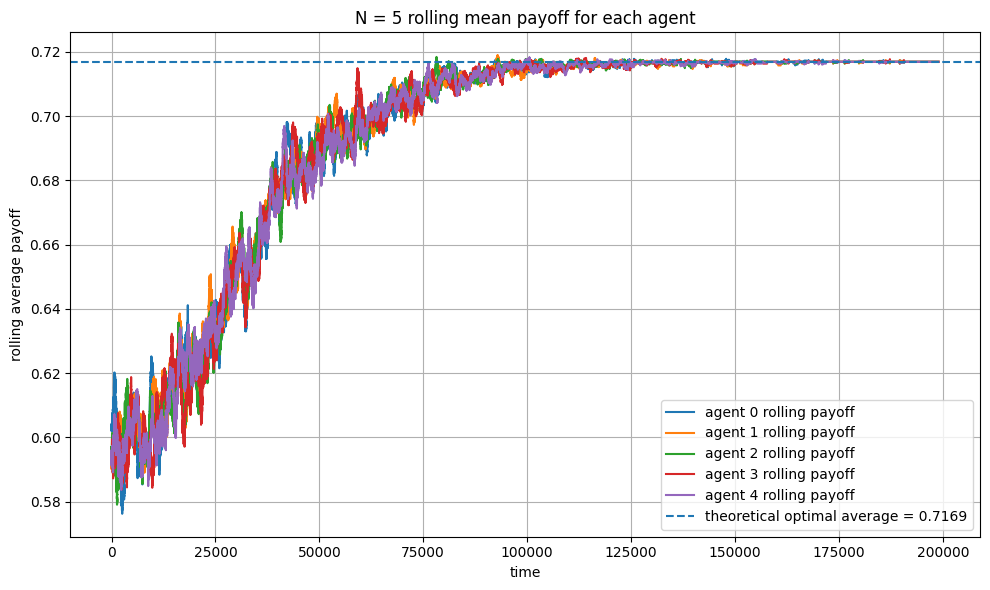


Final average payoff for each agent:
Agent 0: 0.6943
Agent 1: 0.6945
Agent 2: 0.6941
Agent 3: 0.6939
Agent 4: 0.6940

Theoretical fair optimal average payoff:
0.7169

Fairness check:
Mean individual payoff: 0.6942
Std of individual payoff: 0.0002


In [ ]:
# ============================================================
# 5. Plot each agent's rolling payoff vs theoretical fair optimum
# ============================================================

# Reconstruct individual payoff records from action records
# Shape: (episodes, N)
action_records = result["action_records"]

individual_payoff_records = np.zeros((len(action_records), N))

for t, actions in enumerate(action_records):
    payoffs, _ = congestion_payoff(actions, lam=lam)
    individual_payoff_records[t] = payoffs


# Theoretical optimal average payoff per agent
theoretical_avg_optimal = best[2] / N

# Rolling window
window = 1000

def rolling_mean(x, window):
    return np.convolve(x, np.ones(window) / window, mode="valid")


plt.figure(figsize=(10, 6))

for i in range(N):
    rolling_agent_payoff = rolling_mean(
        individual_payoff_records[:, i],
        window
    )

    plt.plot(
        rolling_agent_payoff,
        label=f"agent {i} rolling payoff"
    )

plt.axhline(
    theoretical_avg_optimal,
    linestyle="--",
    label=f"theoretical optimal average = {theoretical_avg_optimal:.4f}"
)

plt.xlabel("time")
plt.ylabel("rolling average payoff")
plt.title(f"N = {N} rolling mean payoff for each agent")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Optional numerical summary
final_average_individual_payoffs = individual_payoff_records.mean(axis=0)

print("\nFinal average payoff for each agent:")
for i, payoff in enumerate(final_average_individual_payoffs):
    print(f"Agent {i}: {payoff:.4f}")

print("\nTheoretical fair optimal average payoff:")
print(f"{theoretical_avg_optimal:.4f}")

print("\nFairness check:")
print(f"Mean individual payoff: {np.mean(final_average_individual_payoffs):.4f}")
print(f"Std of individual payoff: {np.std(final_average_individual_payoffs):.4f}")

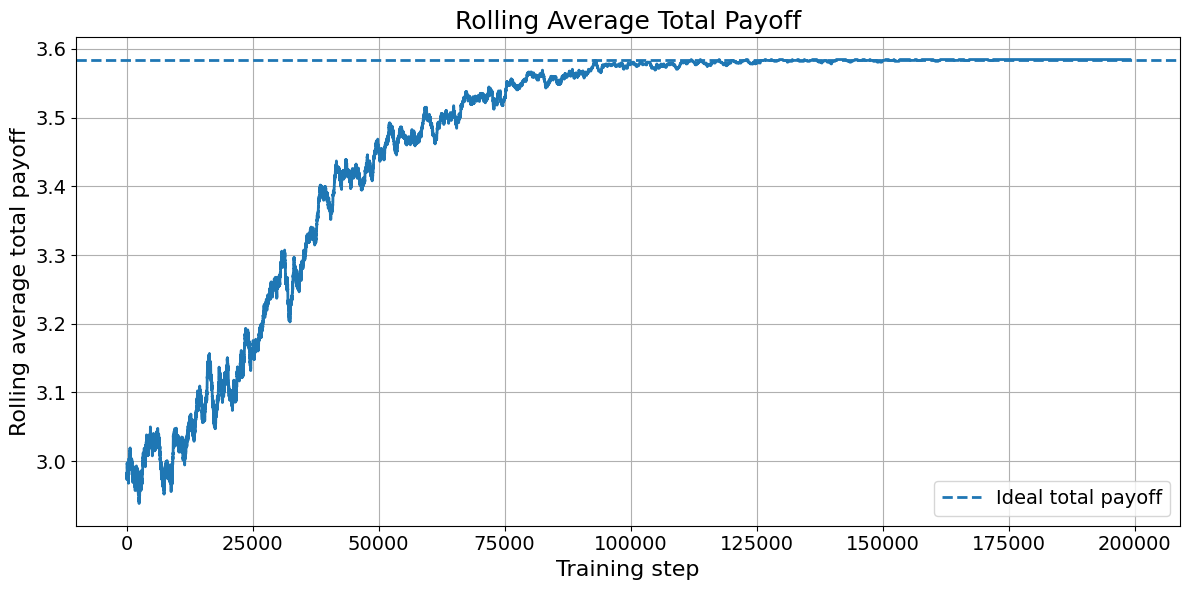

In [ ]:
# ============================================================
# Plot 1: Rolling average total payoff with larger text
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_total_payoff,
    linewidth=2
)

plt.axhline(
    best[2],
    linestyle="--",
    linewidth=2,
    label="Ideal total payoff"
)

plt.xlabel("Training step", fontsize=16)
plt.ylabel("Rolling average total payoff", fontsize=16)
plt.title("Rolling Average Total Payoff", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

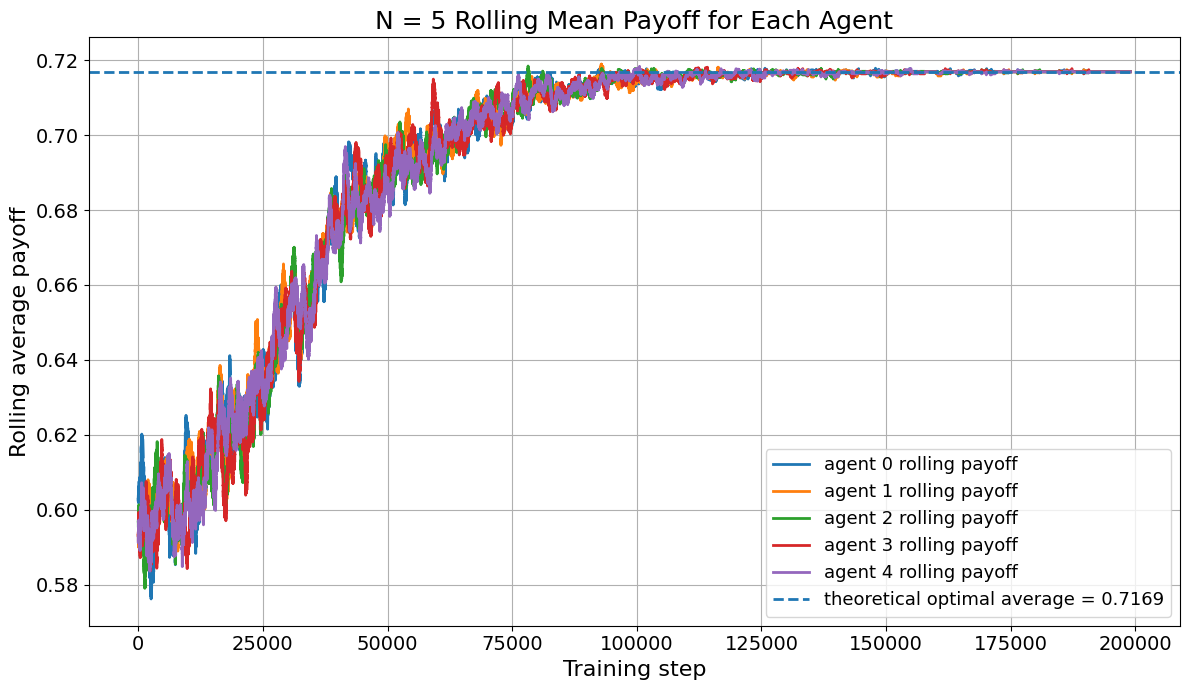

In [ ]:
# ============================================================
# Plot 2: Each agent's rolling average payoff with larger text
# ============================================================

plt.figure(figsize=(12, 7))

for i in range(5):
    rolling_agent_payoff = rolling_mean(
        individual_payoff_records[:, i],
        window
    )

    plt.plot(
        rolling_agent_payoff,
        linewidth=2,
        label=f"agent {i} rolling payoff"
    )

plt.axhline(
    theoretical_avg_optimal,
    linestyle="--",
    linewidth=2,
    label=f"theoretical optimal average = {theoretical_avg_optimal:.4f}"
)

plt.xlabel("Training step", fontsize=16)
plt.ylabel("Rolling average payoff", fontsize=16)
plt.title(f"N = {5} Rolling Mean Payoff for Each Agent", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=13)
plt.grid(True)

plt.tight_layout()
plt.show()


Running robustness test for N = 5
Ideal split: n0=3, n1=2
Ideal total payoff: 3.584586
Ideal average payoff: 0.716917
Training N=5, seed=0...
N=5, seed=0: learned average=0.716917, average gap=-2.220446e-16, fairness loss=0.000000e+00, avg final diff=1.172396e-13
Training N=5, seed=1...
N=5, seed=1: learned average=0.716917, average gap=-2.220446e-16, fairness loss=3.697785e-32, avg final diff=1.172618e-13
Training N=5, seed=2...
N=5, seed=2: learned average=0.716917, average gap=-2.220446e-16, fairness loss=0.000000e+00, avg final diff=1.172396e-13

Running robustness test for N = 7
Ideal split: n0=4, n1=3
Ideal total payoff: 4.828335
Ideal average payoff: 0.689762
Training N=7, seed=0...
N=7, seed=0: learned average=0.689762, average gap=2.220446e-16, fairness loss=8.647467e-10, avg final diff=9.688318e-06
Training N=7, seed=1...
N=7, seed=1: learned average=0.689762, average gap=2.220446e-16, fairness loss=3.991139e-10, avg final diff=6.605672e-06
Training N=7, seed=2...
N=7, seed=

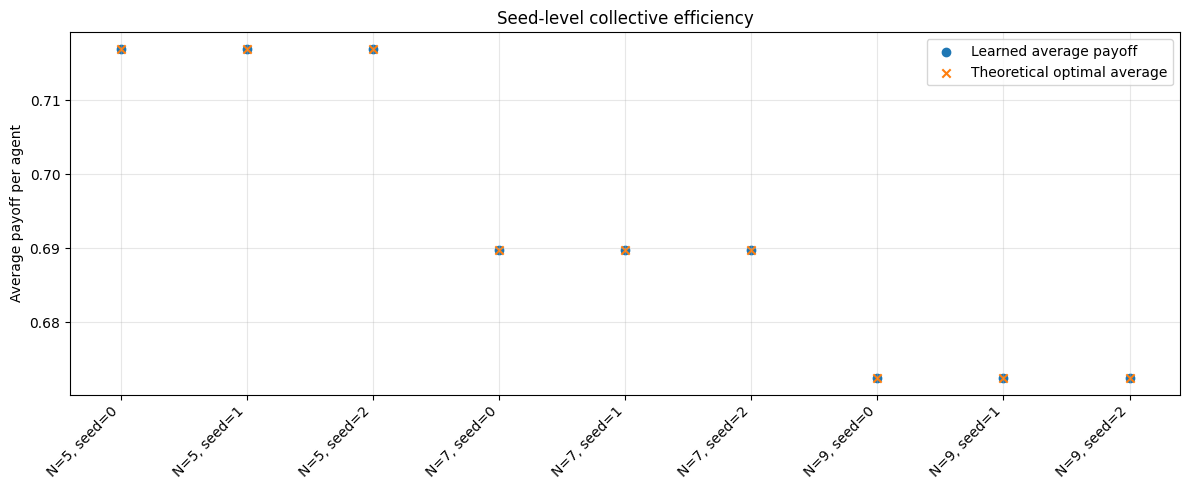

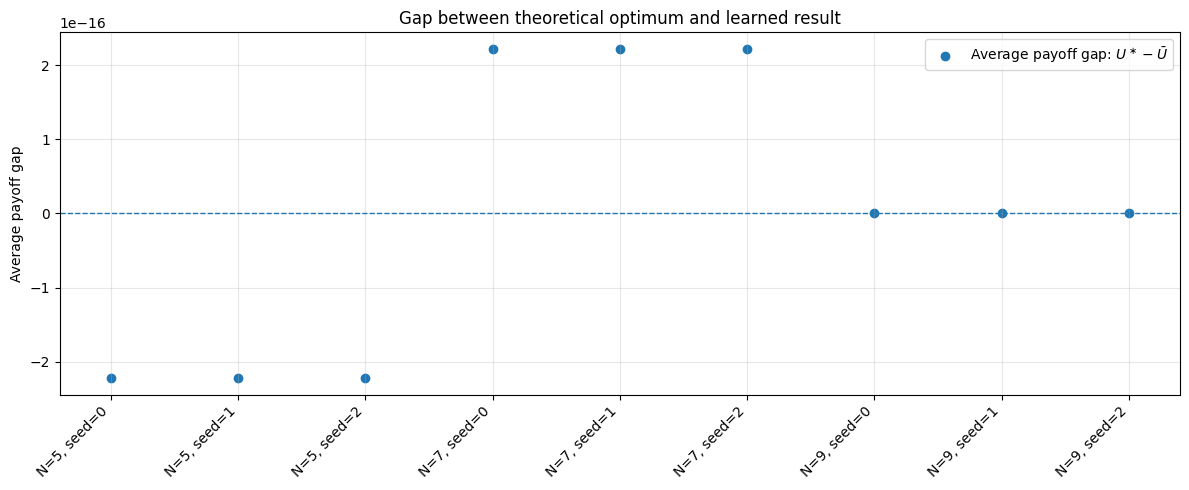

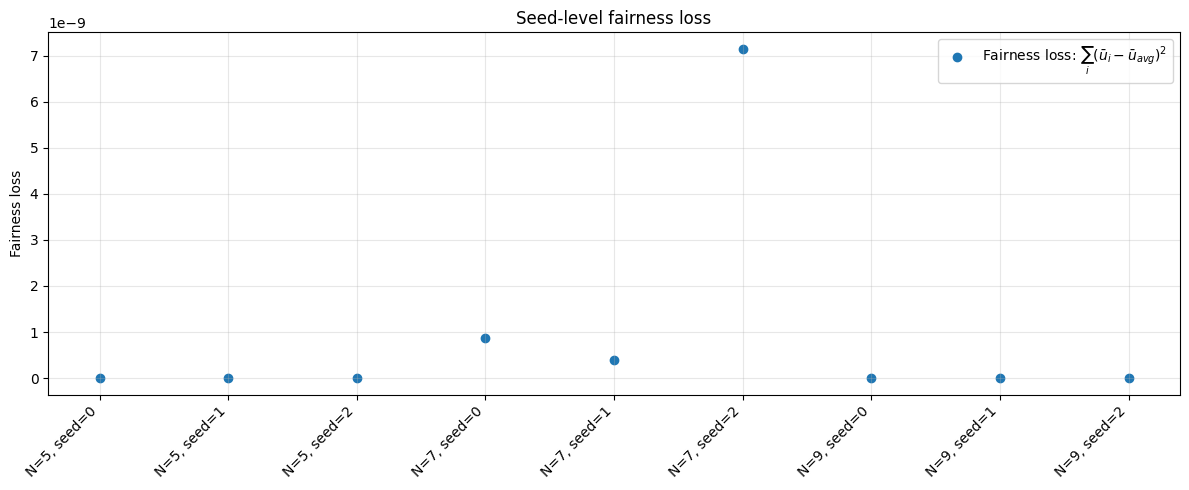

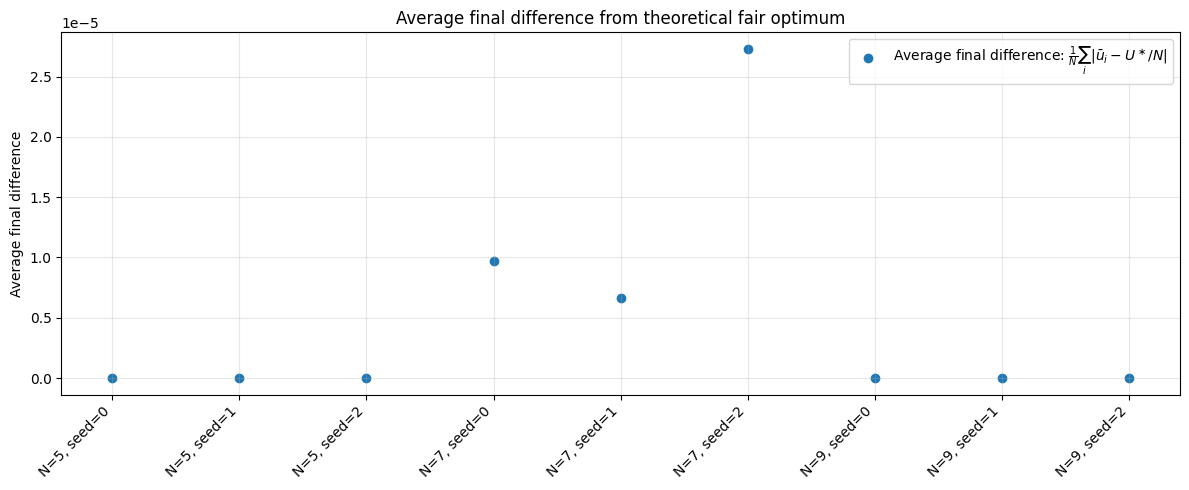



Robustness summary
N=5, seed=0 | ideal avg=0.716917, learned avg=0.716917, avg gap=-2.220446e-16, total gap=-1.332268e-15, fairness loss=0.000000e+00, avg final diff=1.172396e-13
N=5, seed=1 | ideal avg=0.716917, learned avg=0.716917, avg gap=-2.220446e-16, total gap=-1.332268e-15, fairness loss=3.697785e-32, avg final diff=1.172618e-13
N=5, seed=2 | ideal avg=0.716917, learned avg=0.716917, avg gap=-2.220446e-16, total gap=-1.332268e-15, fairness loss=0.000000e+00, avg final diff=1.172396e-13
N=7, seed=0 | ideal avg=0.689762, learned avg=0.689762, avg gap=2.220446e-16, total gap=8.881784e-16, fairness loss=8.647467e-10, avg final diff=9.688318e-06
N=7, seed=1 | ideal avg=0.689762, learned avg=0.689762, avg gap=2.220446e-16, total gap=8.881784e-16, fairness loss=3.991139e-10, avg final diff=6.605672e-06
N=7, seed=2 | ideal avg=0.689762, learned avg=0.689762, avg gap=2.220446e-16, total gap=8.881784e-16, fairness loss=7.150790e-09, avg final diff=2.730344e-05
N=9, seed=0 | ideal avg=0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque


# ============================================================
# 1. Non-linear congestion payoff
# ============================================================

def congestion_payoff(actions, lam=2.0, A=1.0):
    """
    Non-linear congestion payoff.

    actions[i] is either 0 or 1.
    The payoff decreases as more agents choose the same side.
    """
    actions = np.asarray(actions)
    N = len(actions)

    n0 = np.sum(actions == 0)
    n1 = np.sum(actions == 1)
    counts = np.array([n0, n1])

    payoffs = np.zeros(N)

    for i, a in enumerate(actions):
        n_same = counts[a]
        payoffs[i] = A * np.exp(-lam * ((n_same - 1) / (N - 1)) ** 2)

    return payoffs, counts


def ideal_total_payoff(N=5, lam=2.0, A=1.0):
    """
    Brute-force calculation of the best possible total payoff.
    """
    results = []

    for n1 in range(N + 1):
        n0 = N - n1
        W = 0.0

        if n0 > 0:
            W += n0 * A * np.exp(-lam * ((n0 - 1) / (N - 1)) ** 2)

        if n1 > 0:
            W += n1 * A * np.exp(-lam * ((n1 - 1) / (N - 1)) ** 2)

        results.append((n0, n1, W))

    best = max(results, key=lambda x: x[2])
    return best, results


# ============================================================
# 2. Training: phase-based shared Q-learning
# ============================================================

def train_phase_shared_q_learning(
    N=5,
    phase_size=None,
    public_memory=3,
    self_memory=3,
    lam=2.0,
    A=1.0,
    episodes=200000,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.0,
    epsilon_decay=0.99995,
    seed=42
):
    if phase_size is None:
        phase_size = N

    rng = np.random.default_rng(seed)

    Q = defaultdict(lambda: np.zeros(2))

    public_history = deque([0] * public_memory, maxlen=public_memory)

    self_histories = [
        deque([0] * self_memory, maxlen=self_memory)
        for _ in range(N)
    ]

    def get_state(agent_id, t):
        phase = (t + agent_id) % phase_size
        return (
            phase,
            tuple(public_history),
            tuple(self_histories[agent_id])
        )

    for t in range(episodes):
        states = [get_state(i, t) for i in range(N)]

        actions = np.zeros(N, dtype=int)

        for i in range(N):
            if rng.random() < epsilon:
                actions[i] = rng.integers(0, 2)
            else:
                q_values = Q[states[i]]
                max_q = np.max(q_values)
                best_actions = np.flatnonzero(q_values == max_q)
                actions[i] = rng.choice(best_actions)

        payoffs, counts = congestion_payoff(actions, lam=lam, A=A)

        less_crowded_side = int(np.argmin(counts))
        public_history.append(less_crowded_side)

        for i in range(N):
            if counts[less_crowded_side] > 0 and actions[i] == less_crowded_side:
                self_histories[i].append(1)
            else:
                self_histories[i].append(0)

        next_states = [get_state(i, t + 1) for i in range(N)]

        for i in range(N):
            s = states[i]
            a = actions[i]
            r = payoffs[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            td_error = td_target - Q[s][a]
            Q[s][a] += alpha * td_error

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q


# ============================================================
# 3. Evaluation: freeze learning and exploration
# ============================================================

def evaluate_greedy_policy(
    Q,
    N=5,
    phase_size=None,
    public_memory=3,
    self_memory=3,
    lam=2.0,
    A=1.0,
    eval_episodes=20000,
    burn_in=2000,
    seed=123
):
    """
    Evaluate the learned policy with epsilon = 0 and alpha = 0.
    """
    if phase_size is None:
        phase_size = N

    rng = np.random.default_rng(seed)

    public_history = deque([0] * public_memory, maxlen=public_memory)

    self_histories = [
        deque([0] * self_memory, maxlen=self_memory)
        for _ in range(N)
    ]

    total_payoff_records = np.zeros(eval_episodes)
    individual_payoff_records = np.zeros((eval_episodes, N))
    count_records = np.zeros((eval_episodes, 2), dtype=int)

    def get_state(agent_id, t):
        phase = (t + agent_id) % phase_size
        return (
            phase,
            tuple(public_history),
            tuple(self_histories[agent_id])
        )

    for t in range(eval_episodes):
        states = [get_state(i, t) for i in range(N)]

        actions = np.zeros(N, dtype=int)

        for i in range(N):
            q_values = Q[states[i]]
            max_q = np.max(q_values)
            best_actions = np.flatnonzero(q_values == max_q)

            # No exploration, only random tie-breaking if needed
            actions[i] = rng.choice(best_actions)

        payoffs, counts = congestion_payoff(actions, lam=lam, A=A)

        total_payoff_records[t] = np.sum(payoffs)
        individual_payoff_records[t] = payoffs
        count_records[t] = counts

        less_crowded_side = int(np.argmin(counts))
        public_history.append(less_crowded_side)

        for i in range(N):
            if counts[less_crowded_side] > 0 and actions[i] == less_crowded_side:
                self_histories[i].append(1)
            else:
                self_histories[i].append(0)

    # Remove burn-in period
    total_eval = total_payoff_records[burn_in:]
    individual_eval = individual_payoff_records[burn_in:]
    count_eval = count_records[burn_in:]

    return {
        "total_eval": total_eval,
        "individual_eval": individual_eval,
        "count_eval": count_eval
    }


# ============================================================
# 4. Robustness test over N and random seeds
# ============================================================

def robustness_test(
    N_values=(5, 7, 9),
    seeds=(0, 1, 2),
    lam=2.0,
    A=1.0,
    public_memory=3,
    self_memory=3,
    train_episodes=200000,
    eval_episodes=20000,
    burn_in=2000,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.0,
    epsilon_decay=0.99995
):
    records = []

    for N in N_values:
        phase_size = N

        best, _ = ideal_total_payoff(N=N, lam=lam, A=A)
        ideal_total = best[2]
        ideal_average = ideal_total / N

        print(f"\n==============================")
        print(f"Running robustness test for N = {N}")
        print(f"Ideal split: n0={best[0]}, n1={best[1]}")
        print(f"Ideal total payoff: {ideal_total:.6f}")
        print(f"Ideal average payoff: {ideal_average:.6f}")
        print(f"==============================")

        for seed in seeds:
            print(f"Training N={N}, seed={seed}...")

            Q = train_phase_shared_q_learning(
                N=N,
                phase_size=phase_size,
                public_memory=public_memory,
                self_memory=self_memory,
                lam=lam,
                A=A,
                episodes=train_episodes,
                alpha=alpha,
                gamma=gamma,
                epsilon=epsilon,
                epsilon_min=epsilon_min,
                epsilon_decay=epsilon_decay,
                seed=seed
            )

            eval_result = evaluate_greedy_policy(
                Q=Q,
                N=N,
                phase_size=phase_size,
                public_memory=public_memory,
                self_memory=self_memory,
                lam=lam,
                A=A,
                eval_episodes=eval_episodes,
                burn_in=burn_in,
                seed=seed + 1000
            )

            total_eval = eval_result["total_eval"]
            individual_eval = eval_result["individual_eval"]

            learned_total = np.mean(total_eval)
            learned_average = learned_total / N

            agent_average_payoffs = np.mean(individual_eval, axis=0)

            total_gap = ideal_total - learned_total
            average_gap = ideal_average - learned_average

            fairness_loss = np.sum(
                (agent_average_payoffs - np.mean(agent_average_payoffs)) ** 2
            )

            average_final_difference = np.mean(
                np.abs(agent_average_payoffs - ideal_average)
            )

            records.append({
                "N": N,
                "seed": seed,
                "ideal_total": ideal_total,
                "ideal_average": ideal_average,
                "learned_total": learned_total,
                "learned_average": learned_average,
                "total_gap": total_gap,
                "average_gap": average_gap,
                "fairness_loss": fairness_loss,
                "average_final_difference": average_final_difference,
                "agent_average_payoffs": agent_average_payoffs
            })

            print(
                f"N={N}, seed={seed}: "
                f"learned average={learned_average:.6f}, "
                f"average gap={average_gap:.6e}, "
                f"fairness loss={fairness_loss:.6e}, "
                f"avg final diff={average_final_difference:.6e}"
            )

    return records


# ============================================================
# 5. Run robustness experiment
# ============================================================

records = robustness_test(
    N_values=(5, 7, 9),
    seeds=(0, 1, 2),
    lam=2.0,
    A=1.0,
    public_memory=3,
    self_memory=3,
    train_episodes=200000,
    eval_episodes=20000,
    burn_in=2000,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.0,
    epsilon_decay=0.99995
)


# ============================================================
# 6. Convert records into arrays for plotting
# ============================================================

labels = [
    f"N={r['N']}, seed={r['seed']}"
    for r in records
]

learned_averages = np.array([
    r["learned_average"]
    for r in records
])

ideal_averages = np.array([
    r["ideal_average"]
    for r in records
])

average_gaps = np.array([
    r["average_gap"]
    for r in records
])

total_gaps = np.array([
    r["total_gap"]
    for r in records
])

fairness_losses = np.array([
    r["fairness_loss"]
    for r in records
])

average_final_differences = np.array([
    r["average_final_difference"]
    for r in records
])

x = np.arange(len(records))


# ============================================================
# 7. Plot 1: learned average payoff vs theoretical target
# ============================================================

plt.figure(figsize=(12, 5))

plt.scatter(
    x,
    learned_averages,
    label="Learned average payoff",
    marker="o"
)

plt.scatter(
    x,
    ideal_averages,
    label="Theoretical optimal average",
    marker="x"
)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Average payoff per agent")
plt.title("Seed-level collective efficiency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 8. Plot 2: gap between global optimum and learned result
# ============================================================

plt.figure(figsize=(12, 5))

plt.scatter(
    x,
    average_gaps,
    label=r"Average payoff gap: $U^\ast - \bar{U}$",
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Average payoff gap")
plt.title("Gap between theoretical optimum and learned result")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot 3: seed-level fairness loss
# ============================================================

plt.figure(figsize=(12, 5))

plt.scatter(
    x,
    fairness_losses,
    label=r"Fairness loss: $\sum_i(\bar{u}_i-\bar{u}_{avg})^2$",
    marker="o"
)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Fairness loss")
plt.title("Seed-level fairness loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Plot 4: average final difference from fair optimal target
# ============================================================

plt.figure(figsize=(12, 5))

plt.scatter(
    x,
    average_final_differences,
    label=r"Average final difference: $\frac{1}{N}\sum_i|\bar{u}_i-U^\ast/N|$",
    marker="o"
)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Average final difference")
plt.title("Average final difference from theoretical fair optimum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Print final summary
# ============================================================

print("\n\n==============================")
print("Robustness summary")
print("==============================")

for r in records:
    print(
        f"N={r['N']}, seed={r['seed']} | "
        f"ideal avg={r['ideal_average']:.6f}, "
        f"learned avg={r['learned_average']:.6f}, "
        f"avg gap={r['average_gap']:.6e}, "
        f"total gap={r['total_gap']:.6e}, "
        f"fairness loss={r['fairness_loss']:.6e}, "
        f"avg final diff={r['average_final_difference']:.6e}"
    )

print("\nGrouped mean results by N:")
for N in sorted(set(r["N"] for r in records)):
    subset = [r for r in records if r["N"] == N]

    mean_avg_gap = np.mean([r["average_gap"] for r in subset])
    mean_total_gap = np.mean([r["total_gap"] for r in subset])
    mean_fairness_loss = np.mean([r["fairness_loss"] for r in subset])
    mean_avg_final_diff = np.mean([r["average_final_difference"] for r in subset])

    print(
        f"N={N}: "
        f"mean avg gap={mean_avg_gap:.6e}, "
        f"mean total gap={mean_total_gap:.6e}, "
        f"mean fairness loss={mean_fairness_loss:.6e}, "
        f"mean avg final diff={mean_avg_final_diff:.6e}"
    )

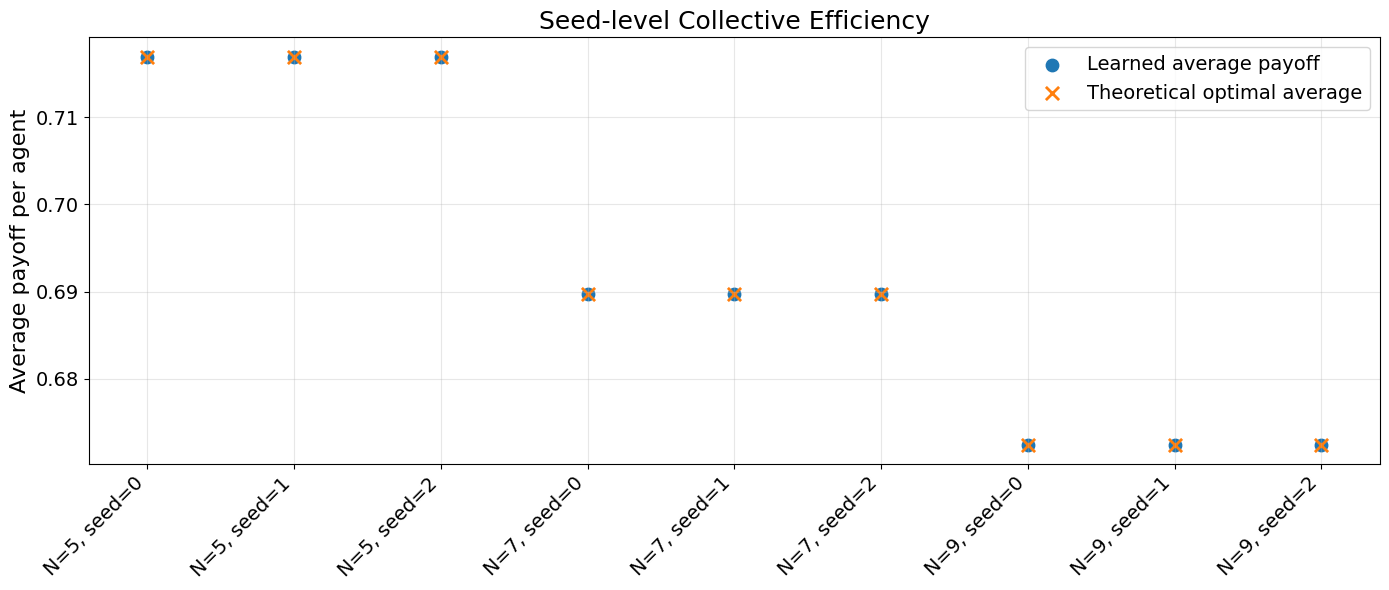

In [ ]:
# ============================================================
# Plot 1: Seed-level collective efficiency with larger text
# ============================================================

plt.figure(figsize=(14, 6))

plt.scatter(
    x,
    learned_averages,
    label="Learned average payoff",
    marker="o",
    s=80
)

plt.scatter(
    x,
    ideal_averages,
    label="Theoretical optimal average",
    marker="x",
    s=90,
    linewidths=2
)

plt.xticks(
    x,
    labels,
    rotation=45,
    ha="right",
    fontsize=14
)

plt.yticks(fontsize=14)

plt.ylabel("Average payoff per agent", fontsize=16)
plt.title("Seed-level Collective Efficiency", fontsize=18)

plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

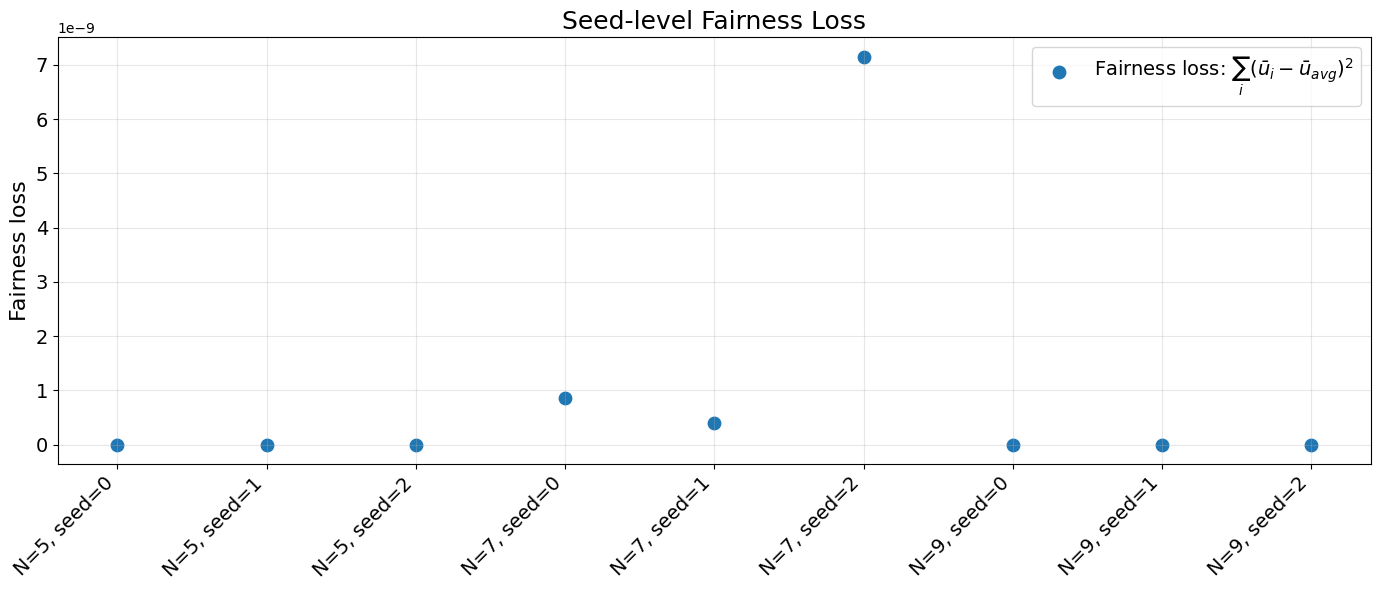

In [ ]:
# ============================================================
# Plot 2: Seed-level fairness loss with larger text
# ============================================================

plt.figure(figsize=(14, 6))

plt.scatter(
    x,
    fairness_losses,
    label=r"Fairness loss: $\sum_i(\bar{u}_i-\bar{u}_{avg})^2$",
    marker="o",
    s=80
)

plt.xticks(
    x,
    labels,
    rotation=45,
    ha="right",
    fontsize=14
)

plt.yticks(fontsize=14)

plt.ylabel("Fairness loss", fontsize=16)
plt.title("Seed-level Fairness Loss", fontsize=18)

plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()